In [1]:
#importing useful python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
# Sklearn tools
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay,precision_score, recall_score, f1_score
#from sklearn.model_selection import cross_val_score

# XGBoost
from xgboost import XGBClassifier


In [2]:
# dataset
positives=pd.read_csv('lightcurve_features_26.csv')
negatives=pd.read_csv('lightcurve_features_26_negative.csv')

In [3]:
combined = pd.concat([positives,negatives])
# Shuffle the combined dataset
combined = combined.sample(frac=1)#.reset_index(drop=True)
combined.to_parquet("biggie_set_with_all_neg_and_pos.parquet", index=False)

print("Combined and shuffled dataset saved")
print("Total rows:", len(combined))

Combined and shuffled dataset saved
Total rows: 1610


In [4]:
df=pd.read_parquet("biggie_set_with_all_neg_and_pos.parquet")

In [5]:
df

,object,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,kurtosis,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,ZTF18aaxaleb,14.644446,14.643584,0.244489,14.558910,0.609695,0.232768,0.250844,0.610502,0.195288,...,0.703586,555.182584,0.113154,0.198834,0.964768,0.016695,111.505669,197.898491,1.095489,0.828932
1,ZTF18abbdqon,15.851452,15.846790,0.141492,15.880691,0.435817,0.356164,0.226216,0.358774,0.121716,...,0.713819,686.295099,0.100690,0.372603,0.465241,0.008926,18.872935,76.116386,0.109126,0.805218
2,ZTF18abccoum,14.562692,14.562952,0.213859,14.632281,1.090097,0.259323,0.344953,0.517027,1.397978,...,0.722516,259.403913,0.111313,0.487665,1.592950,0.014685,52.816745,119.584791,-0.261443,0.845350
3,FH UMa,20.735147,20.451579,0.534805,20.795386,1.349357,0.378788,0.130571,1.320209,-0.508695,...,0.766563,1408.898871,0.416146,0.143939,1.604594,0.025792,0.937369,8.847738,-0.299973,0.816583
4,ZTF18abebmuo,14.613807,14.611317,0.140906,14.650561,0.649249,0.453423,0.387368,0.346015,0.489989,...,0.787052,1128.817919,0.102573,0.380471,0.928578,0.009642,51.660511,96.709575,0.328237,0.865068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,ZTF20aaqtudu,16.503661,16.501116,0.079861,16.488953,0.470840,0.373517,0.377592,0.190155,1.666019,...,0.830551,829.278529,0.060562,0.377889,0.483768,0.004839,26.699868,20.409599,0.216709,0.841890
1606,ZTF22aaetvzs,17.279375,17.264151,0.161072,17.350044,0.640545,0.317949,0.430755,0.413819,-0.749493,...,0.801367,192.628444,0.085571,0.392308,0.813740,0.009322,71.919924,27.461698,-0.576046,0.883248
1607,ZTF17aadnivw,19.018821,18.428603,0.695361,19.280744,1.560374,0.463439,0.222522,1.597212,-1.618725,...,0.918033,1073.738058,0.501968,0.050102,1.850984,0.036562,194.846741,116.731675,-0.205113,0.920504
1608,ZTF18aayvcen,16.814945,16.800948,0.163487,16.776899,0.522308,0.375247,0.365532,0.427969,-0.775374,...,0.851276,453.611179,0.105711,0.246215,0.571169,0.009723,37.208242,66.108490,0.475852,0.833787


In [6]:
#X
X = df.drop(columns=['object']).values

In [7]:
# object column contains names like 'ZTF18abc...' or non-ZTF names : Binary conversion of objects
y = np.where(df['object'].str.contains('ZTF', case=False),
             -1,   # ZTF → negative
              1)   # non-ZTF → positive

In [8]:
print(np.unique(y))


[-1  1]


In [9]:
#doing this as XGBBOOST can't deal with -1 and 1
y[y == -1] = 0


In [10]:
print(np.unique(y))


[0 1]


In [11]:
SEED = 12

train_sizes = np.arange(0.5, 0.91, 0.1)   # train size
n_estimators = np.arange(50, 201, 20)      # number of trees

results = []

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=size,
        shuffle=True,
        random_state=SEED,
        # stratify=y
    )

    # Count classes in this train/test split
    train_positive = np.sum(y_train == 1)
    train_negative = np.sum(y_train == 0)

    test_positive = np.sum(y_test == 1)
    test_negative = np.sum(y_test == 0)

    for n in n_estimators:

        # XGBoost model
        model = XGBClassifier(
            n_estimators=n,
            max_depth=10,
            learning_rate=0.3,
            eval_metric='logloss',
            random_state=SEED
        )

        # Model fitting
        model.fit(X_train, y_train)

        # Prediction
        y_pred = model.predict(X_test)

        # Evaluation
        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, pos_label=1)
        recall = recall_score(y_test, y_pred, pos_label=1)
        f1 = f1_score(y_test, y_pred, pos_label=1)

        # Store results
        results.append({
            "train_size": size,
            "n_estimators": n,
            "max_depth": 10,
            "learning_rate": 0.3,

            # Class counts
            "train_positive": train_positive,
            "train_negative": train_negative,
            "test_positive": test_positive,
            "test_negative": test_negative,

            # Performance
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

results_df = pd.DataFrame(results)

In [12]:
#check
results_df

,train_size,n_estimators,max_depth,learning_rate,train_positive,train_negative,test_positive,test_negative,accuracy,precision,recall,f1_score
0,0.5,50,10,0.3,71,734,68,737,0.951553,0.837209,0.529412,0.648649
1,0.5,70,10,0.3,71,734,68,737,0.954037,0.860465,0.544118,0.666667
2,0.5,90,10,0.3,71,734,68,737,0.954037,0.860465,0.544118,0.666667
3,0.5,110,10,0.3,71,734,68,737,0.954037,0.860465,0.544118,0.666667
4,0.5,130,10,0.3,71,734,68,737,0.954037,0.860465,0.544118,0.666667
5,0.5,150,10,0.3,71,734,68,737,0.954037,0.860465,0.544118,0.666667
6,0.5,170,10,0.3,71,734,68,737,0.954037,0.860465,0.544118,0.666667
7,0.5,190,10,0.3,71,734,68,737,0.954037,0.860465,0.544118,0.666667
8,0.6,50,10,0.3,82,884,57,587,0.962733,0.902439,0.649123,0.755102
9,0.6,70,10,0.3,82,884,57,587,0.962733,0.902439,0.649123,0.755102


In [13]:
# Find best configuration based on precision
best_row = results_df.loc[results_df["precision"].idxmax()]

best_train_size = best_row["train_size"]
best_n_estimators = best_row["n_estimators"]
best_max_depth = best_row["max_depth"]
best_learning_rate = best_row["learning_rate"]

# Training and test class counts
best_train_positive = best_row["train_positive"]
best_train_negative = best_row["train_negative"]
best_test_positive = best_row["test_positive"]
best_test_negative = best_row["test_negative"]

# Performance metrics
best_accuracy = best_row["accuracy"]
best_precision = best_row["precision"]
best_recall = best_row["recall"]
best_f1 = best_row["f1_score"]

print("Best configuration based on precision:")
print(f"Train size        : {best_train_size}")
print(f"n_estimators      : {best_n_estimators}")
print(f"max_depth         : {best_max_depth}")
print(f"learning_rate     : {best_learning_rate}")

print("\nTraining set:")
print(f"CV (positive)     : {int(best_train_positive)}")
print(f"Unknown (negative): {int(best_train_negative)}")
print(f"Total             : {int(best_train_positive + best_train_negative)}")

print("\nTest set:")
print(f"CV (positive)     : {int(best_test_positive)}")
print(f"Unknown (negative): {int(best_test_negative)}")
print(f"Total             : {int(best_test_positive + best_test_negative)}")

print("\nTest performance:")
print(f"Accuracy           : {best_accuracy:.4f}")
print(f"Precision          : {best_precision:.4f}")
print(f"Recall             : {best_recall:.4f}")
print(f"F1-score           : {best_f1:.4f}")

# Save best configuration
best_row.to_frame().T.to_csv(
    "best_configuration_RS_12_1.csv",
    index=False
)

Best configuration based on precision:
Train size        : 0.6
n_estimators      : 50.0
max_depth         : 10.0
learning_rate     : 0.3

Training set:
CV (positive)     : 82
Unknown (negative): 884
Total             : 966

Test set:
CV (positive)     : 57
Unknown (negative): 587
Total             : 644

Test performance:
Accuracy           : 0.9627
Precision          : 0.9024
Recall             : 0.6491
F1-score           : 0.7551


In [14]:
#train the best model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=best_train_size,
    #stratify=y,
    random_state=12
)
#best model with best parameters
best_model = XGBClassifier(
    n_estimators=int(best_n_estimators),
    max_depth=int(best_max_depth),
    learning_rate=float(best_learning_rate),
    eval_metric='logloss',
    n_jobs=-1
)
#fit best model
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=-1,
              num_parallel_tree=None, ...)

In [15]:
#predict model
y_pred = best_model.predict(X_test)
#print(y_pred)


In [16]:
#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
#precision
print("Precision:", precision_score(y_test, y_pred))


Accuracy: 0.9627329192546584
Precision: 0.9024390243902439


In [17]:
probs = best_model.predict_proba(X_test)
#print('probs',probs)

Confusion matrix (raw counts):
[[583   4]
 [ 20  37]]


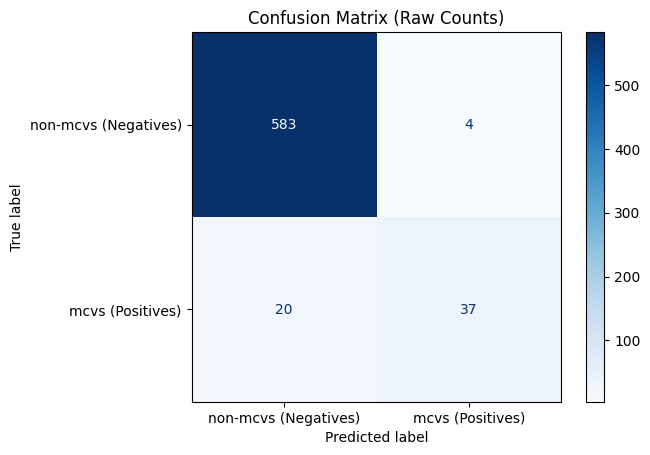

In [18]:
# For best model CONFUSION MATRIX + TP / TN / FP / FN IDENTIFICATION
# Class labels for clarity
class_names = ["non-mcvs (Negatives)", "mcvs (Positives)"]

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay.from_estimator(
   best_model,
    X_test,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues #heatmap
)

disp.ax_.set_title("Confusion Matrix (Raw Counts)")
print("Confusion matrix (raw counts):")
print(disp.confusion_matrix)

plt.show()


# Extract TN, FP, FN, TP explicitly
# Label convention used in  code:
#   0 :ZTF names (negative, non-CV)
#   +1 :non-ZTF names (positive, CV)

cm = confusion_matrix(y_test, best_model.predict(X_test), labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

In [19]:
#saving the best model
joblib.dump(best_model, "cv_classifier_best_model_12_1.pkl")

['cv_classifier_best_model_12_1.pkl']

In [20]:
#from this cell our prev work
# last used hyperparameters
train_size = 0.70
n_estimators = 50
#oter parameters were not varied
# Final train-test split
X_train_prev, X_test_prev, y_train_prev, y_test_prev = train_test_split(
    X,
    y,
    train_size=0.70,
    shuffle=True,
    random_state=12
)

# Train final model
final_model =  XGBClassifier(
    n_estimators=50,
    n_jobs=-1,
    learning_rate=0.1, #Learning rate shrinks the contribution of each tree,Values must be in the range [0.0, inf),values by default float, default=0.1
    max_depth=3, #max_depthint or None, default=3
    eval_metric='logloss',
    random_state=12
)

final_model.fit(X_train_prev, y_train_prev)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=-1,
              num_parallel_tree=None, ...)

In [21]:
#training set
final_model.fit(X_train_prev, y_train_prev)

print("Model trained successfully")


Model trained successfully


In [22]:
#predict model
y_pred = final_model.predict(X_test_prev)
print(y_pred)


[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0]


In [23]:
#accuracy
print("Accuracy:", accuracy_score(y_test_prev, y_pred))


Accuracy: 0.9565217391304348


In [24]:
probs = best_model.predict_proba(X_test_prev)
print('probs',probs)

probs [[9.99398291e-01 6.01715466e-04]
 [9.99563277e-01 4.36748640e-04]
 [9.99861538e-01 1.38460149e-04]
 [9.46604073e-01 5.33959456e-02]
 [9.99869764e-01 1.30223896e-04]
 [9.99365270e-01 6.34742493e-04]
 [9.99490738e-01 5.09271049e-04]
 [9.99519765e-01 4.80219896e-04]
 [9.98651743e-01 1.34828128e-03]
 [9.99028087e-01 9.71883943e-04]
 [9.99825835e-01 1.74151995e-04]
 [9.99734581e-01 2.65426614e-04]
 [9.99734700e-01 2.65316805e-04]
 [1.19640231e-02 9.88035977e-01]
 [5.22534013e-01 4.77465957e-01]
 [9.99826908e-01 1.73111141e-04]
 [1.42790735e-01 8.57209265e-01]
 [9.97172415e-01 2.82758707e-03]
 [9.99825537e-01 1.74449480e-04]
 [9.99840021e-01 1.60008174e-04]
 [9.99823272e-01 1.76724410e-04]
 [9.86478508e-01 1.35214776e-02]
 [9.99650121e-01 3.49894952e-04]
 [9.99936640e-01 6.33614400e-05]
 [9.99819577e-01 1.80419971e-04]
 [9.99907792e-01 9.21822502e-05]
 [9.99758184e-01 2.41814239e-04]
 [9.97478962e-01 2.52104038e-03]
 [9.95101154e-01 4.89883218e-03]
 [9.99680936e-01 3.19036859e-04]
 [9.

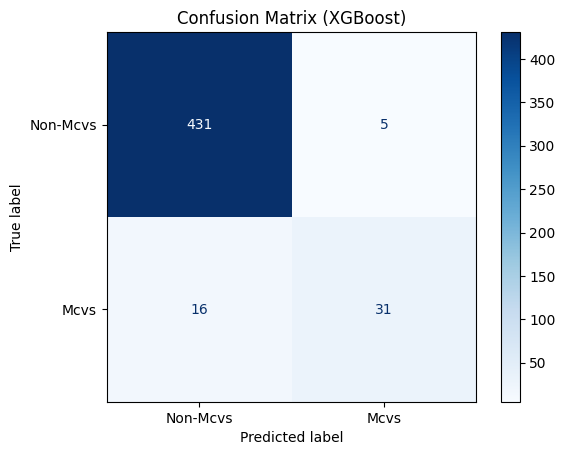

In [25]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test_prev, y_pred, labels=[0, 1])

class_names = ["Non-Mcvs", "Mcvs"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (XGBoost)")
# Save the figure to current directory
#plt.savefig('confusion matrix_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
#extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)

TN: 431 FP: 5 FN: 16 TP: 31


In [27]:
#saving the final model
joblib.dump(final_model, "cv_classifier_xgb_boost_biggie_set_12_1.pkl")

['cv_classifier_xgb_boost_biggie_set_12_1.pkl']